In [1]:
######## Importing the necessary libraries #########


import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline   

In [2]:
##### Fetching the cleaned FM transmitter data for the countries: CANADA, AUSTRALIA and GERMANY ####
#####  EIRP in Watts #####
##### Latitude ranges from 90(N.Pole) to 0 (EQUATOR) to -90(S.Pole) ########
##### Longitude ranges between 0 and 360 degree eastwards ############


#Reading the CSV file
df=pd.read_csv("/media/sf_Shared_Ubuntu/Final_Revised.csv")

#Removing the Null/missing values in the CSV file
df.dropna(subset = ["Latitude in degrees"], inplace=True)


#df.set_index("Area Served", inplace = True) # Set 'Area Served' column as index on a Dataframe
#df=df.loc[["Perth", "Perth City"]] # Using the operator .loc[] to select multiple rows from the Dataframe
df

,Latitude in degrees,Longitude in degrees,Frequency(MHz),EIRP
0,50.947181,8.532986,87.6,164000.0
1,53.509289,10.093932,87.6,131200.0
2,49.832397,9.592726,87.6,41000.0
3,49.629033,7.820645,87.6,820.0
4,49.681928,7.327415,87.6,328.0
...,...,...,...,...
15644,52.294536,181.946878,104.6,164.0
15645,52.115714,182.330147,104.4,1640.0
15646,52.892406,180.655972,104.0,82.0
15647,53.335814,180.171983,104.7,4920.0


In [3]:
np.shape(df)

(14737, 4)

In [4]:
###### User defined frequency axis ######################
fstart=87
fstop=108
fres=0.5
freq=np.arange(fstart,fstop,fres)

#### Array consisting of frequencies from the dataset
data_freq=df['Frequency(MHz)'].values



diff=np.zeros((len(data_freq),len(freq)),dtype=object)
freq_arr=np.zeros(len(data_freq))


for i in range(len(data_freq)):
    for j in range(len(freq)):
        diff[i][j]=abs(data_freq[i]-freq[j])
        freq_arr[i]=freq[np.argmin(diff[i])]

In [5]:
freq

array([ 87. ,  87.5,  88. ,  88.5,  89. ,  89.5,  90. ,  90.5,  91. ,
        91.5,  92. ,  92.5,  93. ,  93.5,  94. ,  94.5,  95. ,  95.5,
        96. ,  96.5,  97. ,  97.5,  98. ,  98.5,  99. ,  99.5, 100. ,
       100.5, 101. , 101.5, 102. , 102.5, 103. , 103.5, 104. , 104.5,
       105. , 105.5, 106. , 106.5, 107. , 107.5])

In [6]:
df['New Frequency']=freq_arr
df

,Latitude in degrees,Longitude in degrees,Frequency(MHz),EIRP,New Frequency
0,50.947181,8.532986,87.6,164000.0,87.5
1,53.509289,10.093932,87.6,131200.0,87.5
2,49.832397,9.592726,87.6,41000.0,87.5
3,49.629033,7.820645,87.6,820.0,87.5
4,49.681928,7.327415,87.6,328.0,87.5
...,...,...,...,...,...
15644,52.294536,181.946878,104.6,164.0,104.5
15645,52.115714,182.330147,104.4,1640.0,104.5
15646,52.892406,180.655972,104.0,82.0,104.0
15647,53.335814,180.171983,104.7,4920.0,104.5


In [7]:
#Resolution of the map
print('-----------Resolution of the map---------') 
nside = 16
print("The number of pixels for the given NSIDE: " + str(hp.nside2npix(nside)))
print("Approximate resolution in degrees for given nside: " + str(np.degrees(hp.nside2resol(nside))))
print( "Pixel area: %.2f square degrees" % hp.nside2pixarea(nside, degrees=True))



-----------Resolution of the map---------
The number of pixels for the given NSIDE: 3072
Approximate resolution in degrees for given nside: 3.6645188392718997
Pixel area: 13.43 square degrees


In [8]:

######-------------------Allocating Pixel number to the Latitude and Longitude of each Tx in the CSV---------#######



# Healpy pixel number when input angles are assumed to be longitude and latitude in degrees
pixel_indices = hp.ang2pix(nside, df['Longitude in degrees'].to_numpy() ,df['Latitude in degrees'].to_numpy(),lonlat=True)
df['Pixel_number']=pixel_indices 
print(pixel_indices)

df

[313 265 365 ... 338 338 338]


Error encountered at /project/healpixsubmodule/src/cxx/Healpix_cxx/healpix_base.cc, line 866
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen

Error encountered at /project/healpixsubmodule/src/cxx/Healpix_cxx/healpix_base.cc, line 866
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen

Error encountered at /project/healpixsubmodule/src/cxx/Healpix_cxx/healpix_base.cc, line 866
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen

/home/yogen14/.local/lib/python3.10/site-packages/healpy/pixelfunc.py:482: RuntimeWarning: invalid value encountered in _ang2pix_ring
  return pixlib._ang2pix_ring(nside, theta, phi)


,Latitude in degrees,Longitude in degrees,Frequency(MHz),EIRP,New Frequency,Pixel_number
0,50.947181,8.532986,87.6,164000.0,87.5,313
1,53.509289,10.093932,87.6,131200.0,87.5,265
2,49.832397,9.592726,87.6,41000.0,87.5,365
3,49.629033,7.820645,87.6,820.0,87.5,365
4,49.681928,7.327415,87.6,328.0,87.5,365
...,...,...,...,...,...,...
15644,52.294536,181.946878,104.6,164.0,104.5,338
15645,52.115714,182.330147,104.4,1640.0,104.5,338
15646,52.892406,180.655972,104.0,82.0,104.0,338
15647,53.335814,180.171983,104.7,4920.0,104.5,338


In [9]:
#######---------------Conversion of the pixel numbers w.r.t the given NSIDE to corresponding angular coordinates--------#######


NPIX = hp.nside2npix(nside) # Storing the number of pixels of the map corresponding to the given NSIDE
arr=np.arange(NPIX) #Create an an array of pixel numbers with respect to the NSIDE

theta, phi = (hp.pix2ang(nside, ipix=arr,lonlat=True)) # Array of the angular coordinates co-latitude(theta) 
                                                        #and longitude(phi) in degrees 
                                                       # With respect to the given NSIDE


In [10]:
#######------------------Altitudes of the satellite orbit--------####


#Creating user defined data points between 400 km to 36000 km in log scale
data_point=int(input("Enter number of data points : "))
altitude= np.logspace(np.log10(400),np.log10(36000),data_point) 
print(altitude)

Enter number of data points : 3
[  400.         3794.7331922 36000.       ]


In [11]:
###########----------------- Calculation of Field of view of the satellite---------#######
###########-----------------Considering Nadir-pointing Field of View Geometry-------######
##########-----------------Considering the FOV of the satellite to be tangent to the surface of the Earth------######


FOV=np.zeros(len(altitude))
for i in range(0,len(altitude)):
# Consider a case of full coverage under elevation of 0 º
    Rad= 6371 # Mean radius of Earth in km
    FOV[i]= 2*np.arcsin(Rad/(Rad+ altitude[i]))  # Field of view for maximal coverage in radians when elevation is 0 º 
    print(" The Field of view of the satellite at a height of",altitude[i],"km is",FOV[i], "radians")

 The Field of view of the satellite at a height of 400.0000000000001 km is 2.4507006996152447 radians
 The Field of view of the satellite at a height of 3794.733192202054 km is 1.3546564445594882 radians
 The Field of view of the satellite at a height of 35999.99999999996 km is 0.30186940950576446 radians


In [12]:
###########----------------- Calculation of the radius of the FOV of the satellite---------#######



# The surface of the coverage area of the Earth depends on the central angle
Central_angle=np.zeros(len(altitude))
for i in range(0,len(altitude)):
    Central_angle[i]=np.arccos(Rad/(Rad+altitude[i])) # Central angle in radians
    
    Dia_of_FOV=2*Central_angle*Rad  # Diameter of the FOV (disc on the Earth's surface)in km
    Rad_of_FOV= Dia_of_FOV/2 # Radius of the FOV in km
    Rad_of_FOV=Rad_of_FOV/Rad  # Radius of the FOV in Radians
    print(" The Radius of the Field of View for a height of",altitude[i],"km in radians is",Rad_of_FOV[i])
len(Rad_of_FOV)

 The Radius of the Field of View for a height of 400.0000000000001 km in radians is 0.3454459769872743
 The Radius of the Field of View for a height of 3794.733192202054 km in radians is 0.8934681045151526
 The Radius of the Field of View for a height of 35999.99999999996 km in radians is 1.4198616220420144


3

In [13]:
###############-----Storing indices of the pixel number that are inside the circle/disc(FOV) wrt the altitude-----------######


vec1 = hp.ang2vec(theta,phi,lonlat=True) #Using ang2vec convert angles that is co-latitude and longitude in radians
                                        #to 3D position vector
    
disc=np.zeros((len(arr),len(Rad_of_FOV)),dtype=object)#Array of indices of the pixel number that are inside the 
                                                      #circle/disc specified by vec and radius
def pixel_disc(a,b):
    for i in range(len(a)):
        for j in range(len(b)):
            disc[j][i]=hp.query_disc(nside, vec1[j], radius=a[i])
pixel_disc(Rad_of_FOV,arr)

In [14]:
#########------- Cross checking the array being created-----#########

df1 = pd.DataFrame(disc)
df1

,0,1,2
0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
...,...,...,...
3067,"[2928, 2929, 2954, 2955, 2956, 2957, 2958, 295...","[2400, 2401, 2402, 2403, 2404, 2405, 2450, 245...","[1632, 1633, 1634, 1635, 1636, 1683, 1684, 168..."
3068,"[2960, 2961, 2962, 2963, 2964, 2965, 2966, 296...","[2464, 2465, 2466, 2467, 2468, 2469, 2470, 247...","[1696, 1697, 1698, 1699, 1700, 1701, 1702, 170..."
3069,"[2965, 2966, 2967, 2968, 2969, 2970, 2971, 297...","[2473, 2474, 2475, 2476, 2477, 2478, 2479, 248...","[1710, 1711, 1712, 1713, 1714, 1715, 1716, 171..."
3070,"[2972, 2973, 2974, 2975, 2976, 2977, 2978, 297...","[2489, 2490, 2491, 2492, 2493, 2494, 2495, 249...","[1726, 1727, 1728, 1729, 1730, 1731, 1732, 173..."


In [15]:
######-----Storing indices of the pixel number that are common between the FOV disc and the satellite pixel no------####


Comm_pix=np.zeros((len(disc[:,i]),len(Rad_of_FOV)),dtype=object)

for i in range(len(Rad_of_FOV)):
    for k in range(len(disc[:,i])):
     

         Comm_pix[k][i]=np.intersect1d(pixel_indices,disc[k][i])#Array of indices of the pixel number that are
                                                           #common between the FOV disc and the satellite pixel no
         

In [16]:
#########------- Cross checking the array being created-----#########


df2 = pd.DataFrame(Comm_pix)
df2

,0,1,2
0,"[54, 78]","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106...","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106..."
1,"[54, 99]","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106...","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106..."
2,"[54, 78, 99, 100, 101, 102, 103, 104, 105, 106]","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106...","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106..."
3,"[54, 78, 103, 104, 105, 106]","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106...","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106..."
4,[54],"[54, 78, 99, 100, 101, 102, 103, 104, 105, 106...","[54, 78, 99, 100, 101, 102, 103, 104, 105, 106..."
...,...,...,...
3067,[],"[2403, 2404, 2616]","[1746, 1841, 1910, 1911, 1912, 1913, 1974, 197..."
3068,[],"[2553, 2554, 2616]","[1778, 1783, 1785, 1841, 1847, 1848, 1849, 191..."
3069,[],"[2489, 2490, 2553, 2554, 2616]","[1778, 1783, 1785, 1841, 1847, 1848, 1849, 191..."
3070,[],"[2489, 2490, 2553, 2554, 2616]","[1746, 1783, 1785, 1841, 1847, 1848, 1849, 191..."


In [19]:
######--- Initializing the array to store the pixel number that are common between the FOV disc ---####
######                        and the satellite pixel no    ######


### THIS CELL NEEDS TO BE CORRECTED ###
### ALERT: Once executed it will show error 
##           Move on and execute the next cell which will again show an error
##           Come back execute this cell again and then execute the next cell


Comm_TX=np.zeros((len(Comm_pix[:,j]),len(Rad_of_FOV)),dtype=object)
found_common=np.zeros(( len(Comm_pix[:,j]),len(Rad_of_FOV)),dtype=object)

In [20]:
######-----Storing indices of the pixel number that are common between the FOV disc and the satellite pixel no ------#
######-----And the same pixel number of the transmitters-----##

#Comm_TX=np.zeros((len(Comm_pix[:,j]),len(Rad_of_FOV)),dtype=object)
#found_common=np.zeros(( len(Comm_pix[:,j]),ln(Comm_pix[:,j])en(Rad_of_FOV)),dtype=object)

for j in range(len(Rad_of_FOV)):
    for i in range(len(Comm_pix[:,j])):
        Comm_TX[i][j]=set(Comm_pix[i][j])
        found_common[i][j] = [l for l in pixel_indices if l in Comm_TX[i][j]]#Array of indices of the pixel number that 
                                                    #are common between the FOV disc and the satellite pixel no with
                                                    # Tx having same pixel number
                                                                       
         

In [21]:
#########------- Cross checking the array being created-----#########

df3 = pd.DataFrame(found_common)
df3

,0,1,2
0,"[78, 78, 54, 78]","[313, 265, 365, 365, 365, 312, 365, 365, 365, ...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ..."
1,"[54, 99]","[313, 265, 365, 365, 365, 312, 365, 365, 365, ...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ..."
2,"[101, 101, 101, 101, 102, 101, 101, 101, 102, ...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ..."
3,"[78, 103, 103, 103, 106, 105, 78, 54, 104, 104...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ..."
4,[54],"[313, 265, 365, 365, 365, 312, 365, 365, 365, ...","[313, 265, 365, 365, 365, 312, 365, 365, 365, ..."
...,...,...,...
3067,[],"[2616, 2616, 2616, 2616, 2616, 2616, 2616, 261...","[2490, 1746, 2490, 2424, 2424, 2424, 2424, 242..."
3068,[],"[2554, 2554, 2554, 2553, 2553, 2553, 2553, 261...","[2490, 2490, 2424, 2424, 2424, 2424, 2424, 242..."
3069,[],"[2490, 2490, 2490, 2490, 2490, 2490, 2490, 249...","[2490, 2490, 2424, 2424, 2424, 2424, 2424, 242..."
3070,[],"[2490, 2490, 2490, 2490, 2490, 2490, 2490, 249...","[2490, 1746, 2490, 2424, 2424, 2424, 2424, 242..."


In [22]:
#######-------Store the values of the received power in Watt,dBm and Kelvin wrt altitude----#####
######------- Calculation of the received power using Friis Transmission Equation--------#######
######-------Considering isotropic transmitter and receiver with gain =1 -------------#########





res=fres*1e6 #Bandwidth
Rx_Power= np.zeros((len(df),len(altitude)))
Rx_Power_in_Kelvin=np.zeros((len(df),len(altitude)))
for i in range(0,len(altitude)):
    for j in range(0,len(df)):
        wavelength= (3*1e8)/(df.iloc[j]['Frequency(MHz)']*1e6)
        Rx_Power[j][i]= ((df.iloc[j]['EIRP'])*(wavelength)**2)/(4*np.pi*altitude[i])**2 #the Friis Transmission Equation
        
        Rx_Power_in_Kelvin[j][i]=Rx_Power[j][i]/(1.38*1e-23*res)#in Kelvin
        #df9[j][i]=pd.DataFrame(Rx_Power_in_Kelvin[j][i])

In [23]:
##### ---Create dataframe to store the values of the received power in Kelvin w.r.t the altitude----#####

##### The first three columns of the dataframe indicate the altitude [0=400 km, 1= 3794 km , 2= 36000 km ] #####
##### The column will vary with the user input for the number of altitudes ######

df_data=pd.DataFrame(Rx_Power_in_Kelvin)
df_data['Pixel_number']=pixel_indices
df_data['New Frequency']=freq_arr


df_data

,0,1,2,Pixel_number,New Frequency
0,1.103289e+16,1.225877e+14,1.362085e+12,313,87.5
1,8.826313e+15,9.807015e+13,1.089668e+12,265,87.5
2,2.758223e+15,3.064692e+13,3.405213e+11,365,87.5
3,5.516446e+13,6.129384e+11,6.810427e+09,365,87.5
4,2.206578e+13,2.451754e+11,2.724171e+09,365,87.5
...,...,...,...,...,...
14732,7.738097e+12,8.597886e+10,9.553207e+08,338,104.5
14733,7.767774e+13,8.630860e+11,9.589844e+09,338,104.5
14734,3.913820e+12,4.348689e+10,4.831877e+08,338,104.0
14735,2.316997e+14,2.574441e+12,2.860490e+10,338,104.5


In [28]:
######--- Initializing the array to store the dataframes for the FOV for each pixel position of the satellite #####
######            at different altitudes   ######


##### THE CELL NEEDS TO BE CORRECTED  #####
### ALERT: Once executed it will show error 
##           Move on and execute the next cell which will again show an error
##           Come back execute this cell again and then execute the next cell


df_1=np.zeros((len(found_common[:,j]),len(Rad_of_FOV)),dtype=object)

In [29]:
#########  Create dataframes for the FOV for each pixel position of the satellite at different altitudes #######



#df_1=np.zeros((len(found_common[:,j]),len(Rad_of_FOV)),dtype=object)
for j in range(len(Rad_of_FOV)):
    for i in range(len(found_common[:,j])):
        df_1[i][j]= df_data.loc[df_data['Pixel_number'].isin(found_common[i][j])]
        df_1[i][j]= df_1[i][j].groupby(['New Frequency']).sum()  # df9['Pixel_number']= Column consisting of 
        df_1[i][j]= df_1[i][j].reset_index()                                                 #the values of pixel number of the transmitters 
                                                                    #based on the resolution of the map
        
        
       
#df_1.drop['Pixel_number']

In [30]:
# Dataframe showing the pixel numbers(or Transmitters with their respective operating frequency)in the
# FOV of the satellite at an altitude 400 km when overhead pixel position(or number) 0
    
       # First 0 indicate the pixel position(or number)
       # Second 0 indicate the altitude [0=400 km, 1= 3794 km , 2= 36000 km ]



df_1[0][0]

,New Frequency,0,1,2,Pixel_number
0,90.0,5.214564e+12,5.793960e+10,6.437733e+08,78
1,105.0,1.287661e+13,1.430734e+11,1.589704e+09,132
2,107.0,0.000000e+00,0.000000e+00,0.000000e+00,78


In [31]:
# Dataframe showing the pixel numbers(or Transmitters with their respective operating frequency)in the
# FOV of the satellite at an altitude 400 km when overhead pixel position(or number) 2
    

df_1[2][0]

,New Frequency,0,1,2,Pixel_number
0,88.0,3.130600e+13,3.478445e+11,3.864939e+09,299
1,90.0,1.045235e+13,1.161373e+11,1.290414e+09,182
2,90.5,6.532110e+12,7.257900e+10,8.064333e+08,306
3,97.5,7.184449e+12,7.982721e+10,8.869690e+08,406
4,98.5,1.100861e+13,1.223179e+11,1.359088e+09,205
5,100.0,4.623417e+13,5.137130e+11,5.707922e+09,404
6,100.5,1.669816e+12,1.855351e+10,2.061501e+08,202
7,102.0,1.141503e+13,1.268337e+11,1.409264e+09,406
8,105.0,3.127176e+13,3.474640e+11,3.860711e+09,546
9,106.5,1.859126e+12,2.065695e+10,2.295217e+08,101


In [32]:
# Dataframe showing the pixel numbers(or Transmitters with their respective operating frequency)in the
# FOV of the satellite at an altitude 3794 km when overhead pixel position(or number) 0
    

df_1[0][1]

,New Frequency,0,1,2,Pixel_number
0,87.5,3.720320e+16,4.133689e+14,4.592988e+12,13020
1,88.0,4.335940e+17,4.817711e+15,5.353013e+13,182334
2,88.5,5.822275e+17,6.469195e+15,7.187994e+13,199542
3,89.0,2.814403e+17,3.127115e+15,3.474572e+13,100677
4,89.5,4.075585e+17,4.528428e+15,5.031586e+13,145938
5,90.0,2.853932e+17,3.171035e+15,3.523372e+13,128673
6,90.5,3.539285e+17,3.932539e+15,4.369488e+13,140734
7,91.0,2.955455e+17,3.283839e+15,3.648710e+13,113559
8,91.5,3.211703e+17,3.568559e+15,3.965065e+13,160098
9,92.0,2.873467e+17,3.192741e+15,3.547490e+13,115506


In [33]:
## Initializing the 3D array to store the received power for each pixel, each frequency and at different altitudes ###

power_output=np.zeros((len(Rad_of_FOV),NPIX,len(freq)),dtype=object)


In [34]:
## Create the 3D array to store the received power for each pixel, each frequency and at different altitudes ##
## k: loops along the length of the number of altitude
## m: loops along the length of the number of pixels based on the given NSIDE
## l: loops along the length of the number of frequencies in the frequency axis defined by user


for k in range(len(Rad_of_FOV)):
    for m in range(NPIX):    
        for l in range(len(freq)):
            if (df_1[m][k][k][df_1[m][k]['New Frequency'] == freq[l]].values).size==0:# checking for empty dataframes
                power_output[k][m][l]=0
            else: 
                power_output[k][m][l]=float(df_1[m][k][k][df_1[m][k]['New Frequency'] == freq[l]].values)
           
        

/tmp/ipykernel_3535/2174957613.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  power_output[k][m][l]=float(df_1[m][k][k][df_1[m][k]['New Frequency'] == freq[l]].values)


In [35]:
##Received power by the satellite at an altitude 400 km when overhead pixel position(or number) 0 at all frequencies##

power_output[0,0,:]

array([0, 0, 0, 0, 0, 0, 5214563716236.782, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       12876605953099.73, 0, 0, 0, 0.0, 0], dtype=object)

Text(0.5, 0.98, 'Power spectrum for pixel 0 at an altitude of 400 km')

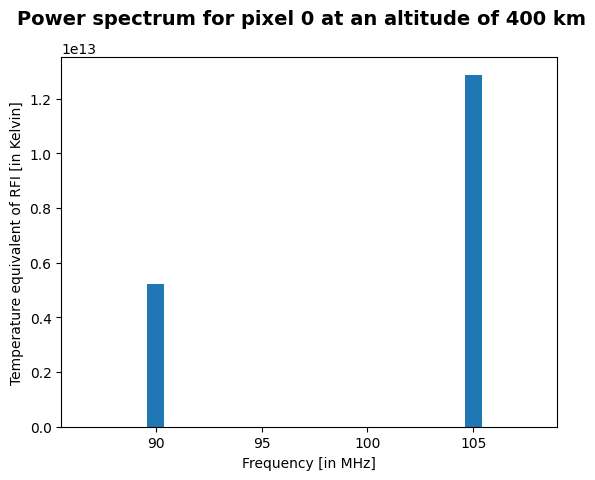

In [36]:
##Power spectrum for pixel 1 at an altitude of 400 km

plt.bar(freq,power_output[0,0,:]) 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Temperature equivalent of RFI [in Kelvin]')
plt.suptitle('Power spectrum for pixel 0 at an altitude of 400 km',fontsize=14, fontweight="bold")

In [37]:
##Received power by the satellite at an altitude 400 km when overhead pixel position(or number) 2 at all frequencies##

power_output[0,2,:]

array([0, 0, 31306003968484.87, 0, 0, 0, 10452354859040.04,
       6532109787861.705, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       7184448690229.081, 0, 11008612200949.352, 0, 0, 46234171738817.52,
       1669815971182.7483, 0, 0, 11415034376612.045, 0, 0, 0, 0, 0,
       31271757314670.773, 0, 0, 1859125577587.81, 590484635078.221, 0],
      dtype=object)

Text(0.5, 0.98, 'Power spectrum for pixel 2 at an altitude of 400 km')

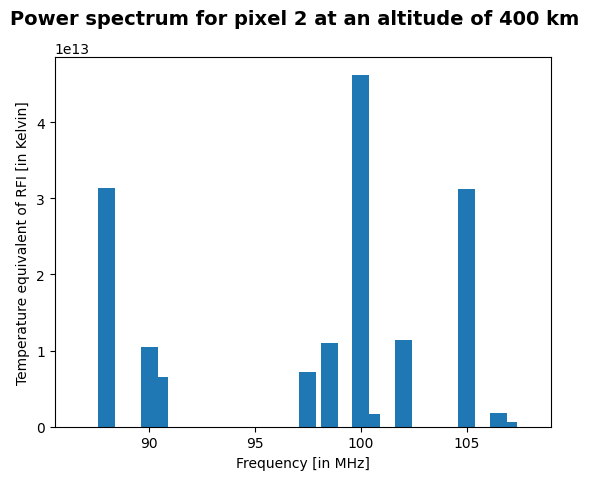

In [38]:
##Power spectrum for pixel 2 at an altitude of 400 km

plt.bar(freq,power_output[0,2,:]) 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Temperature equivalent of RFI [in Kelvin]')
plt.suptitle('Power spectrum for pixel 2 at an altitude of 400 km',fontsize=14, fontweight="bold")

In [39]:
##Received power by the satellite at an altitude 3794 km when overhead pixel position(or number) 0 at all frequencies##

power_output[1,0,:]

array([0, 413368940932702.44, 4817711256640778.0, 6469194982889202.0,
       3127114902636990.0, 4528427673519572.0, 3171035169462397.5,
       3932539379163917.5, 3283839257437652.0, 3568558810447768.5,
       3192740828945383.0, 3459045351537501.5, 2364598511763143.0,
       2640361823639670.5, 2207030159083420.2, 4088601266300507.5,
       2529163440452495.0, 3462697156721887.5, 2344681704394117.0,
       3628401552329162.5, 1891668322161757.0, 3148793962677508.0,
       2430432309587722.5, 3189397144792898.0, 2434213550041107.5,
       2306655917669978.5, 2424249494700274.5, 3183838723762631.5,
       2248424865874421.5, 2439497861822621.0, 1960876113334886.2,
       2892924536551602.5, 1913580826054681.5, 2787559933080856.0,
       2511338528603613.0, 2392576850117568.5, 2288061274615090.0,
       3182307304503453.0, 2179827623094634.0, 2366783324453939.5,
       1786423937807860.0, 3704295506137766.0], dtype=object)

Text(0.5, 0.98, 'Power spectrum for pixel 0 at an altitude of 3794 km')

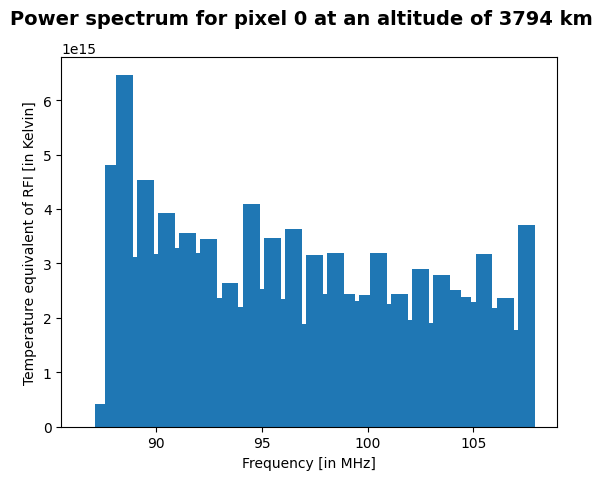

In [40]:
##Power spectrum for pixel 0 at an altitude of 3794 km

plt.bar(freq,power_output[1,0,:]) 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Temperature equivalent of RFI [in Kelvin]')
plt.suptitle('Power spectrum for pixel 0 at an altitude of 3794 km',fontsize=14, fontweight="bold")

In [41]:
##Received power by the satellite at an altitude 36000 km when overhead pixel position(or number) 0 at all frequencies##

power_output[2,0,:]

array([6488486986964.581, 4593219787096.668, 87623990542259.9,
       93798865413468.69, 36867357468413.54, 51699374007126.336,
       35555610754288.22, 46246196303047.32, 37659764519043.07,
       41909835532329.41, 36007067586626.41, 39008758062243.27,
       27709823010680.145, 29937723970962.543, 25115279745926.78,
       45569357570137.734, 28461599972119.77, 38474412852465.47,
       26120209861391.492, 40876786052156.88, 21018536912908.44,
       35118543703207.78, 27004803439863.62, 35837710536196.7,
       27046817222679.008, 26549343577262.227, 27520266295126.035,
       35438077249876.24, 24982498509715.83, 27421049900486.81,
       21787512370387.652, 32452248204042.707, 21507839367514.58,
       31276538356850.11, 27961632607698.535, 27122248759839.21,
       25422903051278.816, 35884647910685.14, 24220306923273.746,
       27044043274987.945, 19849154864531.805, 41158838957086.34],
      dtype=object)

Text(0.5, 0.98, 'Power spectrum for pixel 0 at an altitude of 36000 km')

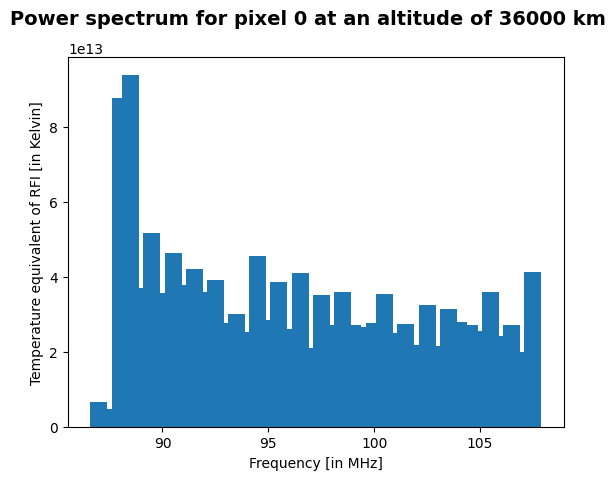

In [42]:
##Power spectrum for pixel 0 at an altitude of 36000 km #####

plt.bar(freq,power_output[2,0,:]) 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Temperature equivalent of RFI [in Kelvin]')
plt.suptitle('Power spectrum for pixel 0 at an altitude of 36000 km',fontsize=14, fontweight="bold")

In [43]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 400 km at 90 MHz----------------------#######

test_plot = np.zeros(hp.nside2npix(nside))
test_plot[0:np.size(power_output[0,:,6])] = power_output[0,:,6]
print(np.shape(test_plot))

(3072,)


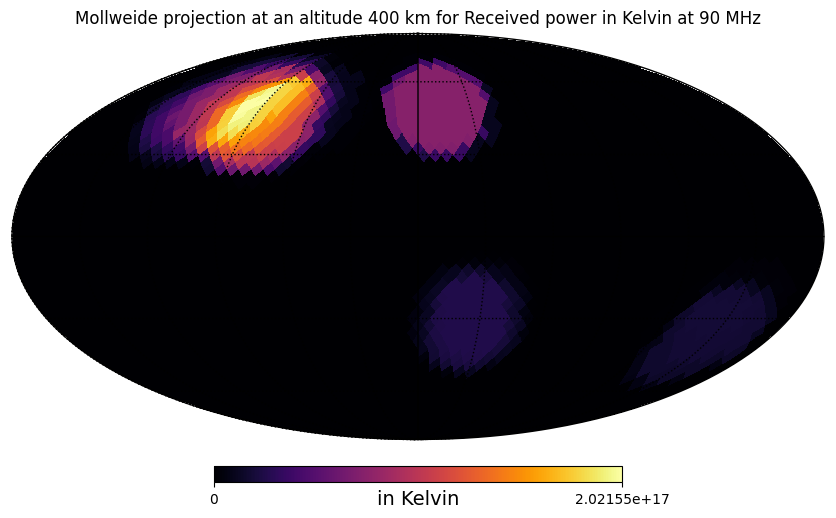

In [44]:
hp.mollview(test_plot,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 400 km for Received power in Kelvin at 90 MHz",flip='geo')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [45]:
# Replacing the power value of 0 to a minimum value 1.000001 in order to apply logarithmic equalization in 
# the Healpy map


power_output_log=np.where(power_output[0,:,6]==0, 1.0000001, power_output[0,:,6])
np.shape(power_output_log)

(3072,)

In [46]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 400 km at 90 MHz with logarithmic equalization----------------------#######


test_plot12 = np.zeros(hp.nside2npix(nside))
test_plot12[0:np.size(power_output[0,:,6])] = power_output_log
test_plot12=np.where(test_plot12==0, 1.0000001,test_plot12 )

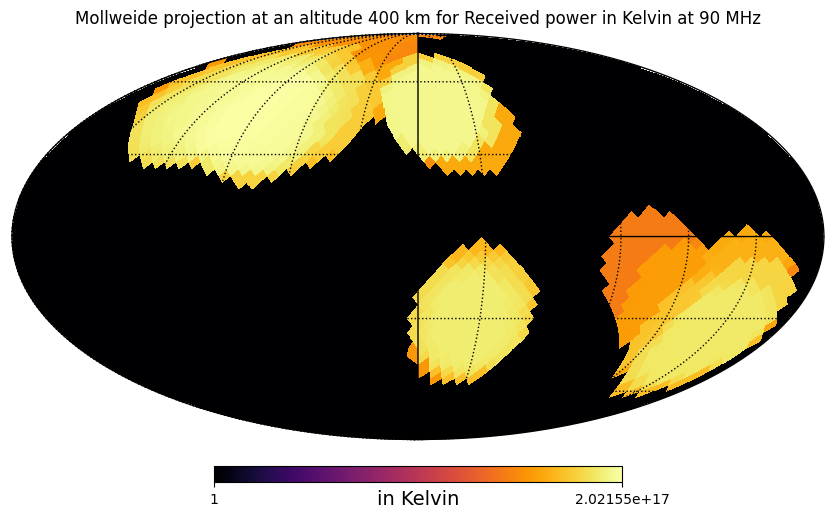

In [47]:

hp.mollview(test_plot12,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 400 km for Received power in Kelvin at 90 MHz",flip='geo',norm="log")#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()
plt.show()

In [48]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 400 km at 100 MHz----------------------#######


test_plot1 = np.zeros(hp.nside2npix(nside))
test_plot1[0:np.size(power_output[0,:,26])] = power_output[0,:,26]


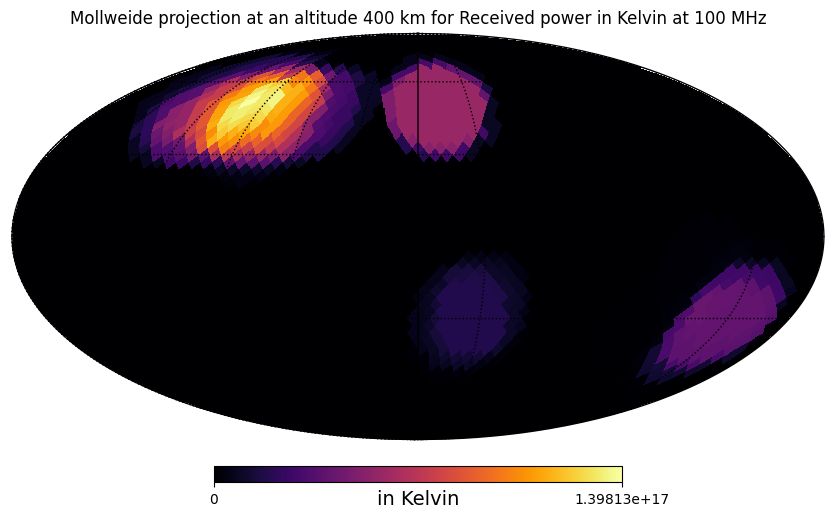

In [49]:
hp.mollview(test_plot1,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 400 km for Received power in Kelvin at 100 MHz",flip='geo')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [50]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 3794 km at 90 MHz----------------------#######


test_plot4 = np.zeros(hp.nside2npix(nside))
test_plot4[0:np.size(power_output[1,:,6])] = power_output[1,:,6]

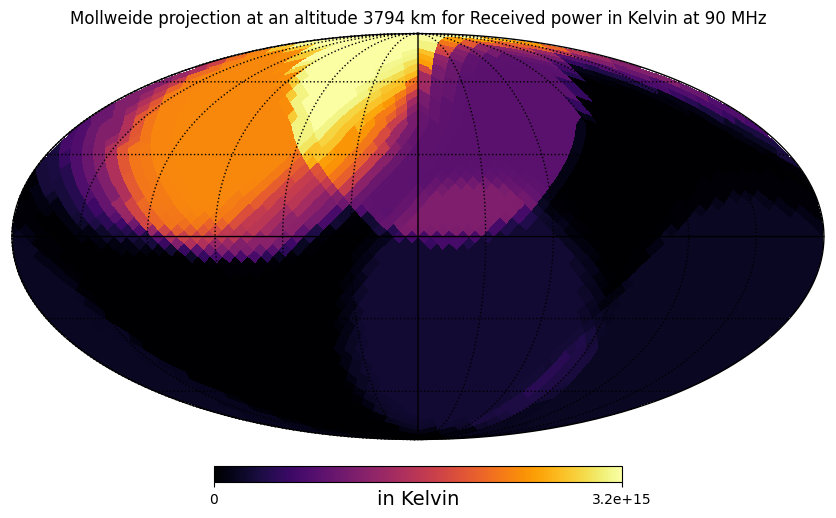

In [51]:

hp.mollview(test_plot4,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 3794 km for Received power in Kelvin at 90 MHz",flip='geo')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()
plt.show()

In [52]:
# Replacing the power value of 0 to a minimum value 1.000001 in order to apply logarithmic equalization in 
# the Healpy map


power_output_log1=np.where(power_output[1,:,6]==0, 1.0000001, power_output[1,:,6])
np.shape(power_output_log1)

(3072,)

In [53]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 3794 km at 90 MHz with logarithmic equalization----------------------#######


test_plot13 = np.zeros(hp.nside2npix(nside))
test_plot13[0:np.size(power_output[1,:,6])] = power_output_log1
test_plot13=np.where(test_plot13==0, 1.0000001,test_plot13 )

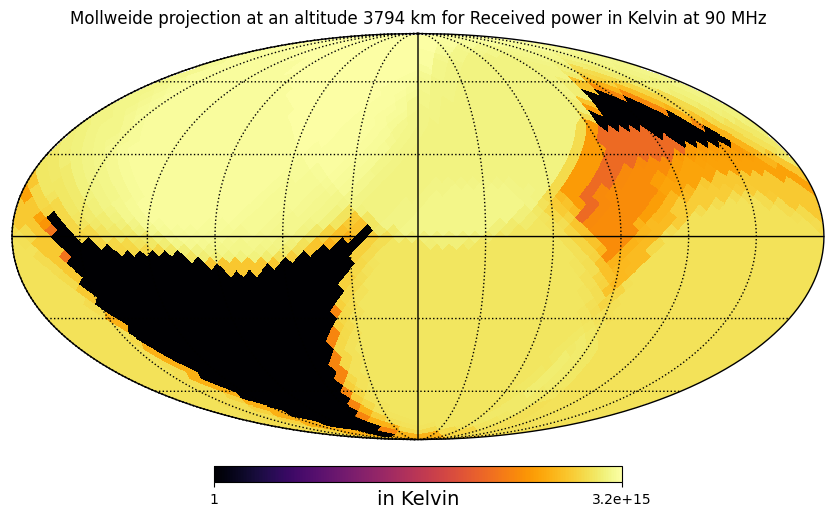

In [54]:
hp.mollview(test_plot13,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 3794 km for Received power in Kelvin at 90 MHz",flip='geo',norm="log")#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [55]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 3794 km at 100 MHz----------------------#######


test_plot2 = np.zeros(hp.nside2npix(nside))
test_plot2[0:np.size(power_output[1,:,26])] = power_output[1,:,26]


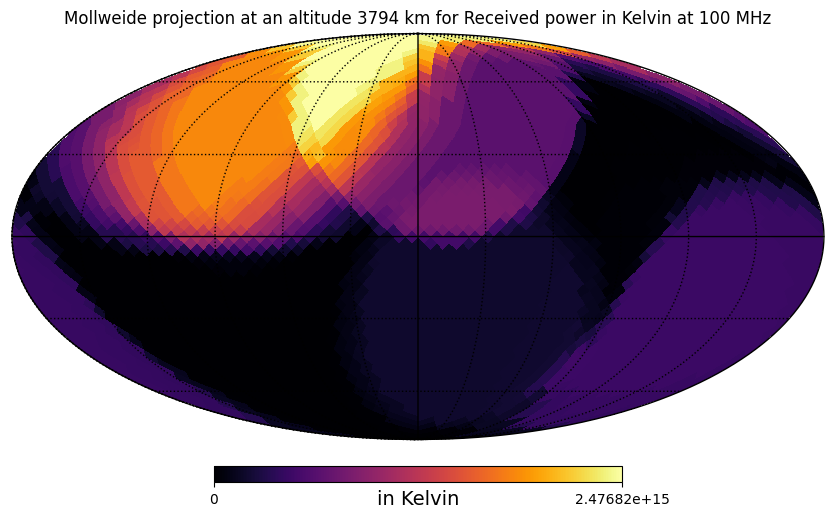

In [56]:
hp.mollview(test_plot2,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 3794 km for Received power in Kelvin at 100 MHz",flip='geo')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [57]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 36000 km at 90 MHz----------------------#######


test_plot5 = np.zeros(hp.nside2npix(nside))
test_plot5[0:np.size(power_output[2,:,6])] = power_output[2,:,6]

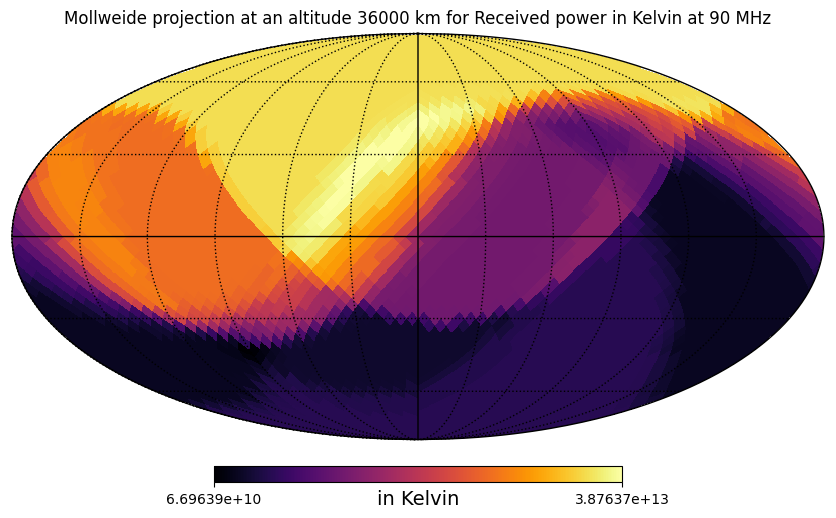

In [58]:
hp.mollview(test_plot5,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 36000 km for Received power in Kelvin at 90 MHz",flip='geo')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [59]:
# Replacing the power value of 0 to a minimum value 1.000001 in order to apply logarithmic equalization in 
# the Healpy map


power_output_log2=np.where(power_output[2,:,6]==0, 1.0000001, power_output[2,:,6])
np.shape(power_output_log2)

(3072,)

In [60]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 36000 km at 90 MHz with logarithmic equalization----------------------#######


test_plot14 = np.zeros(hp.nside2npix(nside))
test_plot14[0:np.size(power_output[2,:,6])] = power_output_log2
test_plot14=np.where(test_plot14==0, 1.0000001,test_plot14 )

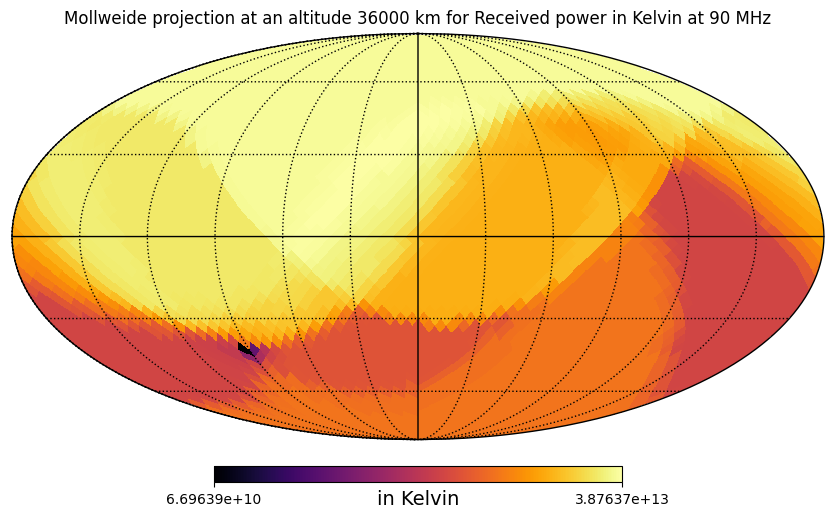

In [61]:
hp.mollview(test_plot14,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 36000 km for Received power in Kelvin at 90 MHz",flip='geo',norm="log")#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [62]:
###-------Plotting of the Healpy Map in mollweide projection------###
#####------For an altitude of 36000 km at 100 MHz----------------------#######


test_plot3 = np.zeros(hp.nside2npix(nside))
test_plot3[0:np.size(power_output[2,:,26])] = power_output[2,:,26]


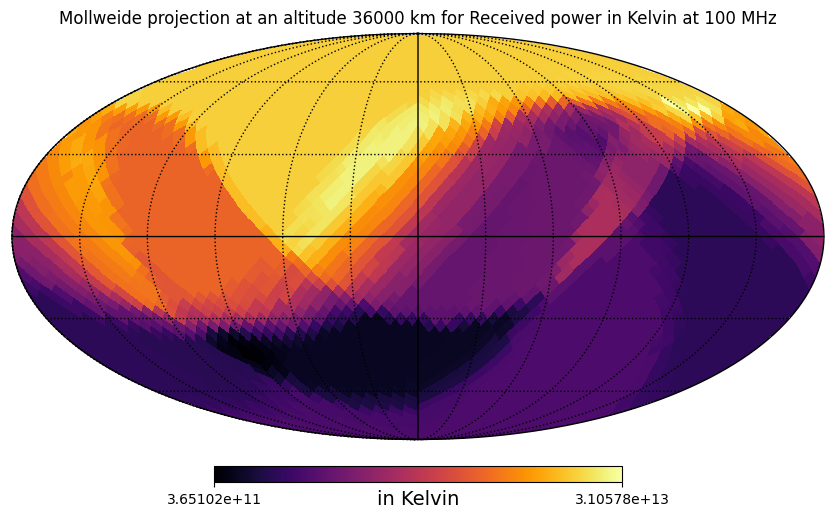

In [63]:
hp.mollview(test_plot3,cmap='inferno',unit="in Kelvin",title="Mollweide projection at an altitude 36000 km for Received power in Kelvin at 100 MHz",flip='geo')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import healpy as hp

In [65]:
##Read the tif file##
image = tiff.imread('/media/sf_Shared_Ubuntu/MAPS/GPW_2020_1deg.tif')
array = np.array(image)
# Initialize constants
subdivision_rows = 2
subdivision_cols = 2
nside=16
# Calculate the dimensions of the new array
new_rows = len(array) * subdivision_rows
new_cols = len(array[0]) * subdivision_cols

# Initialize the new array with zeros
image_array = np.zeros((new_rows, new_cols), dtype=array.dtype)

# Iterate through each element in the original array
for i in range(len(array)):
    for j in range(len(array[0])):
        original_element = array[i][j]
        
        # Fill the subdivisions with the original element value
        for x in range(subdivision_rows):
            for y in range(subdivision_cols):
                image_array[i * subdivision_rows + x][j * subdivision_cols + y] = original_element


In [66]:
# Define the spherical coordinates#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

# Set angular resolution#


## Make empty healpix mask and pixel values vector##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)

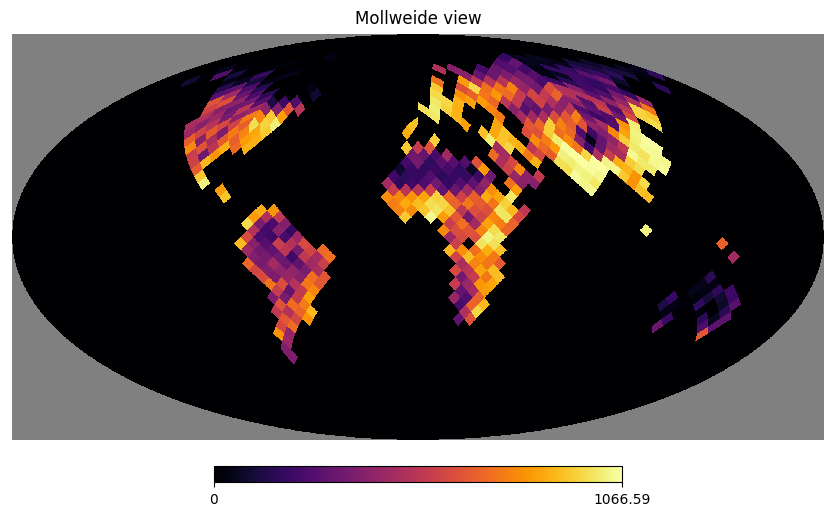

In [67]:
for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

# Average value of each pixel#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]

hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()

In [68]:
nonzeroindex=(test_plot12>8*10**8)
print(nonzeroindex)
nonzerotp=test_plot12[nonzeroindex]
print(np.shape(nonzerotp))

[ True False  True ... False False False]
(927,)


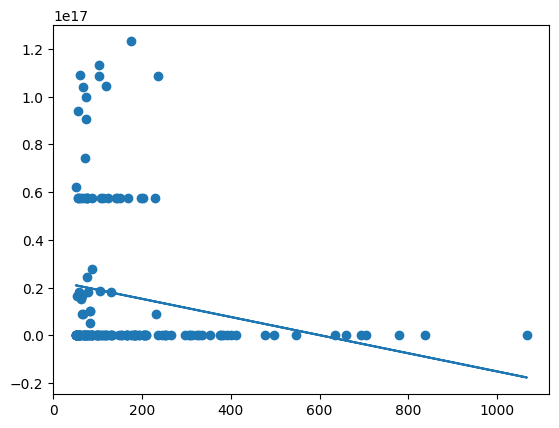

In [71]:
from sklearn.linear_model import LinearRegression
nonzeroindex = (healpix_map > 50)

true_indices = np.where(nonzeroindex)[0]
thm=healpix_map[true_indices].reshape(-1,1)
ttp=test_plot1[true_indices].reshape(-1,1)
model = LinearRegression()
model.fit(thm, ttp)
ttp_pred = model.predict(thm)
plt.plot(thm,ttp_pred)
plt.scatter(thm,ttp)


plt.show()



In [ ]:
hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
hp.mollview(test_plot3, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()

In [ ]:
nonzeromask=(healpix_map>0)
nzhm=healpix_map[nonzeromask]
#np.shape(nzhm)
pixel=np.where(nonzeromask)[0]
np.shape(test_plot[pixel])
plt.scatter(healpix_map[pixel],test_plot7[pixel])
plt.show()

In [ ]:
plt.bar(healpix_map[pixel],pixel)

NameError: name 'power_output' is not defined